In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC,SVC
from sklearn.naive_bayes import MultinomialNB


## preprocess reduced data

### relabel data and enumerate words

In [3]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 3,
    "crime": 4,
    
    "science": 5,
    "psychology": 6,
    "history": 7,
    "travel": 8,
    "sports": 9
}
class_number = 10

In [ ]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 2,
    "crime": 2,
    
    "science": 3,
    "psychology": 3,
    "history": 3,
    "travel": 3,
    "sports": 3
}
class_number = 4

In [4]:
dataset = pd.read_csv("reduced.csv")

dataset["label"] = dataset["label"].map(mapped_dict)
# change words to numbers
dataset=dataset.dropna()

In [5]:
X_train,X_test,y_train,y_test = train_test_split(dataset["text"],dataset["label"],test_size=0.4,stratify=dataset["label"])
X_val,X_test,y_val,y_test = train_test_split(X_test,y_test,test_size=0.5,stratify=y_test)


print("Size of training set: ", len(X_train))
print("Size of validation set: ", len(X_val))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = y_train.value_counts()
print(statistics)

print("Validation set classes distribution:")
statistics = y_val.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = y_test.value_counts()
print(statistics)

Size of training set:  13785
Size of validation set:  4595
Size of test set:  4595
Training set classes distribution: 
label
0    4478
1    4247
7    1618
3     883
4     642
6     539
5     493
2     490
8     240
9     155
Name: count, dtype: int64
Validation set classes distribution:
label
0    1493
1    1416
7     539
3     294
4     214
6     180
5     164
2     163
8      80
9      52
Name: count, dtype: int64
Test set classes distribution:
label
0    1492
1    1416
7     540
3     294
4     214
6     179
2     164
5     164
8      80
9      52
Name: count, dtype: int64


## vectorization

In [6]:
count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
X_val_counts = count_vectorizer.transform(X_val)

### tfidf

In [ ]:
tfidf = TfidfVectorizer()
X_train_counts = tfidf.fit_transform(X_train)
X_test_counts = tfidf.transform(X_test)
X_val_counts = tfidf.transform(X_val)

# podejście OvR

              precision    recall  f1-score   support

           0       0.80      0.88      0.84      1493
           1       0.79      0.85      0.82      1416
           2       0.62      0.45      0.52       163
           3       0.56      0.49      0.53       294
           4       0.68      0.55      0.60       214
           5       0.60      0.43      0.50       164
           6       0.74      0.66      0.70       180
           7       0.73      0.71      0.72       539
           8       0.56      0.28      0.37        80
           9       0.82      0.54      0.65        52

    accuracy                           0.76      4595
   macro avg       0.69      0.58      0.63      4595
weighted avg       0.75      0.76      0.75      4595



<Axes: >

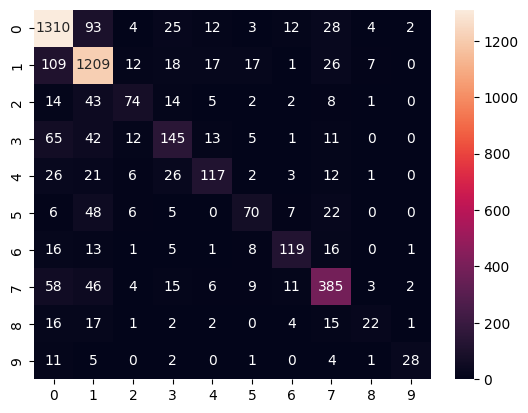

In [7]:
# create svm classifier for each label
classifiers = []
r_vectors=[]
for i in range(class_number):
    
    bayes_clf = MultinomialNB(alpha = 1.0, fit_prior=True)
    bayes_clf.fit(X_train_counts, y_train == i)
    r = bayes_clf.feature_log_prob_[1]-bayes_clf.feature_log_prob_[0]
    r_vectors.append(r)

    X_train_nbsvm = X_train_counts.multiply(r)

    # clf = SVC(kernel='rbf', C=1.0, tol=1e-2,verbose=True, class_weight='balanced', max_iter=2000)
    clf = LinearSVC(C=0.1,tol=1e-2, loss='squared_hinge', class_weight='balanced', max_iter=2000, dual=False)
    clf.fit(X_train_nbsvm, y_train == i)
    classifiers.append(clf)
# evaluate each classifier on validation set
all_scores=np.zeros((X_val_counts.shape[0], class_number))
for i in range(class_number):
    r = r_vectors[i]
    X_val_nbsvm = X_val_counts.multiply(r)
    all_scores[:, i] = classifiers[i].decision_function(X_val_nbsvm)

final_predictions = np.argmax(all_scores, axis=1)
print(classification_report(y_val, final_predictions))
sns.heatmap(confusion_matrix(y_val, final_predictions),annot=True, fmt='d')

# podejście OvO

              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1493
           1       0.72      0.90      0.80      1416
           2       0.65      0.31      0.42       163
           3       0.63      0.39      0.49       294
           4       0.75      0.51      0.61       214
           5       0.68      0.39      0.50       164
           6       0.77      0.58      0.66       180
           7       0.74      0.71      0.72       539
           8       0.82      0.17      0.29        80
           9       1.00      0.38      0.56        52

    accuracy                           0.75      4595
   macro avg       0.76      0.52      0.59      4595
weighted avg       0.75      0.75      0.73      4595



<Axes: >

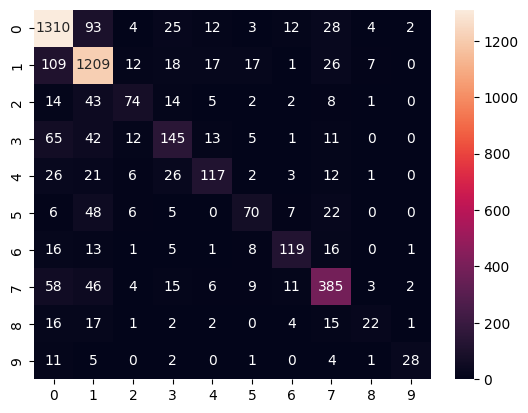

In [ ]:
classifiers = {}
r_vectors={}
unique_classes = sorted(list(set(y_train.values)))
for idx, i in enumerate(unique_classes):
    for j in unique_classes[idx + 1:]:
        
        mask = (y_train.values == i) | (y_train.values == j)
        
        X_train_pair = X_train_counts[mask]
        y_train_pair = (y_train.values[mask] == i).astype(int)
        
        # create weights using Naive Bayes
        bayes_clf = MultinomialNB(alpha = 1.0, fit_prior=True)
        bayes_clf.fit(X_train_pair, y_train_pair)
        r = bayes_clf.feature_log_prob_[1]-bayes_clf.feature_log_prob_[0]
        r_vectors[(i,j)] = r
        
        
        X_train_nb = X_train_pair.multiply(r)
        
        clf = LinearSVC(C=1.0,tol=1e-2, loss='squared_hinge',class_weight='balanced', max_iter=2000)
        clf.fit(X_train_nb, y_train_pair)
        classifiers[(i,j)] = clf

confidence_scores=np.zeros((X_val_counts.shape[0], class_number))
for (i,j), clf in classifiers.items():
    r = r_vectors[(i,j)]
    X_val_nbsvm = X_val_counts.multiply(r)
    score = clf.decision_function(X_val_nbsvm)
    confidence_scores[:, i] += score
    confidence_scores[:, j] -= score

finals = np.argmax(confidence_scores, axis=1)
print(classification_report(y_val, finals))
sns.heatmap(confusion_matrix(y_val, finals),annot=True, fmt='d')

<Axes: >

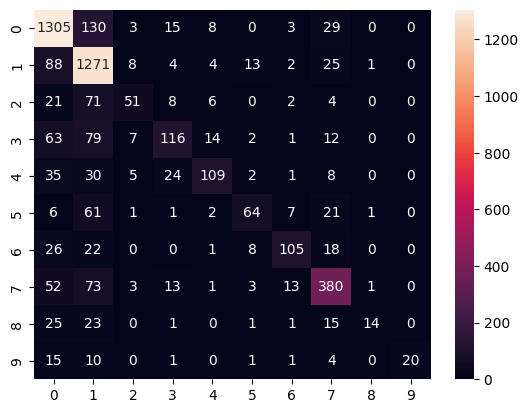

In [11]:
sns.heatmap(confusion_matrix(y_val, finals),annot=True, fmt='d')